NN MODULE


In [ ]:

import torch
import torch.nn as nn
import torch.optim as opt

w=torch.tensor(0.0,requires_grad=True)
#1.Class structure
# class MyModel(nn.Module):
#     def __init__(self):
#         super().__init__() #<---- very important to call the parent class constructor,it initializes the internal state of the module, and it is necessary for the module to work properly.
#         self.w=nn.Parameter(torch.tensor(0.0))
#         def forward(self,x):
#             return self.w*x 

#2. Layers: is a building block of neural networks, it is a module that takes an input tensor and produces an output tensor. Layers can be combined to create complex models. PyTorch provides a wide range of pre-defined layers, such as linear layers, convolutional layers, recurrent layers, etc.
# layer=nn.Linear(3,2) #<---- means 3 input features, 2 output features
# x=torch.tensor([[1.0,2.0,3.0]]) #<---- input tensor with shape (1,3)
# y=layer(x) #<---- output tensor with shape (1,2)
# print(y) #<---- print the output tensor

#3. Activation functions: are used to introduce non-linearity into the model, which allows it to learn complex patterns in the data. PyTorch provides a wide range of pre-defined activation functions, such as ReLU, Sigmoid, Tanh, etc.
# activation=nn.ReLU() #<---- ReLU activation function,used while dealing with Hidden layers
# activation=nn.Sigmoid() #<---- Sigmoid activation function,used if need output between binary (0 and 1)
# activation=nn.Tanh() #<---- Tanh activation function,used while dealing with the hidden layers, it is similar to sigmoid but it outputs values between -1 and 1
# activation=nn.Softmax(dim=1) #<---- Softmax activation function,used while dealing with multi-class classification problems,need multi-class o/p
# activation=nn.LeakyReLU() #<---- LeakyReLU activation function,used while dealing with the hidden layers, it is similar to ReLU but it allows a small gradient when the input is negative

#4 Optimizers: are used to update the model parameters during training, based on the gradients computed during backpropagation. PyTorch provides a wide range of pre-defined optimizers, such as SGD, Adam, RMSprop, etc.
# optimizer=torch.optim.SGD([w],lr=0.01) #<---- Stochastic Gradient Descent optimizer, used to update the model parameters during training, [w]=model parameters, lr=learning rate. move slowly towards the target o/p
# optimizer=torch.optim.Adam([w],lr=0.01) #<---- Adam optimizer, used to update the model parameters during training, [w]=model parameters, lr=learning rate, adapts the learning rate for each parameter. used for faster learning
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Linear=nn.Linear(1, 1)
    def forward(self,x):
        return self.Linear(x)

#Data
x=torch.tensor([[1.0],[2.0],[3.0],[4.0]])
y=torch.tensor([[2.0],[4.0],[6.0],[8.0]])

#Model
model=MyModel()

#Loss & Optimizers
loss_fn=nn.MSELoss() #<---- Mean Squared Error loss function, used to measure the difference between the predicted and actual values, used for regression problems
optimizer=opt.Adam(model.parameters(),lr=0.1)

#Training Loop
for epoch in range(10):
    optimizer.zero_grad() #<---- zero the gradients before backpropagation
    y_pred=model(x)
    loss=loss_fn(y_pred,y)
    loss.backward() #<---- compute the gradients
    optimizer.step() #<---- update the model parameters
    print(f'Epoch {epoch+1}: loss={loss.item()}') 

#5 Saving and Loading Models: PyTorch provides a simple way to save and load models using the torch.save() and torch.load() functions. This allows you to save the model parameters to a file and load them later for inference or further training.
torch.save(model.state_dict(),'linear_model.pth') 

DATALOADER

In [ ]:
#Dataloader job is to take data from dataset & divide it into batches,then shuffle the batches and at last feed the batches to the model for training


MNIst Classifier Project

Using device: cpu
Epoch 1/5: Loss = 0.3352
Epoch 2/5: Loss = 0.1390
Epoch 3/5: Loss = 0.0967
Epoch 4/5: Loss = 0.0724
Epoch 5/5: Loss = 0.0575
Total Accuracy: 97.44%
Model saved as mnist_model.pth


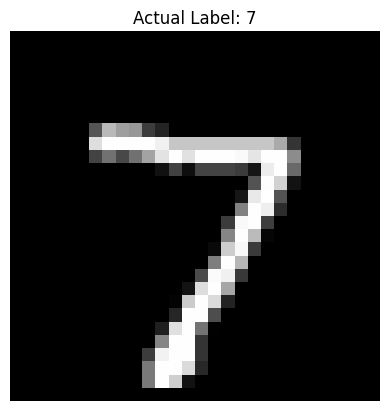

User picked image index: 0
Actual Label: 7
Model Prediction: 7


In [11]:
# import torch
# import torch.nn as nn
# import torch.optim as opt
# from torchvision.datasets import MNIST
# from torchvision import transforms
# from torch.utils.data import DataLoader
# import matplotlib.pyplot as plt
# import transformers

# device="cuda" if torch.cuda.is_available() else "cpu"
# print("Using device:",device)


# transform=transforms.ToTensor() #<---- convert the images to tensors

# train_data=MNIST(root='data',train=True,download=True,transform=transform) #<---- download the MNIST dataset and apply the transform

# test_data=MNIST(root='data',train=False,download=True,transform=transform) #<---- download the MNIST dataset and apply the transform

# train_loader=DataLoader(train_data,batch_size=64,shuffle=True) #<---- create a DataLoader for the training data, batch_size=64 means 64 images per batch, shuffle=True means shuffle the data before creating batches

# test_loader=DataLoader(test_data,batch_size=64,shuffle=False) #<---- create a DataLoader for the test data, batch_size=64 means 64 images per batch, shuffle=False means do not shuffle the data before creating batches

# class MyModel(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.net=nn.Sequential(
#             nn.Linear(28*28,128), #<---- input layer, 28*28=784 input features, 128 output features
#             nn.ReLU(), #<---- activation function
#             nn.Linear(128,64), #<---- hidden layer, 128 input features, 64 output features
#             nn.ReLU(), #<---- activation function
#             nn.Linear(64,10) #<---- output layer, 64 input features, 10 output features (for 10 classes)
#         )
#     def forward(self,x):
#         return self.net(x)

# model=MyModel().to(device) #<---- move the model to the device (GPU or CPU)
# loss_fn=nn.CrossEntropyLoss() #<---- Cross Entropy loss function, used to measure the difference between the predicted and actual values, used for classification problems
# optimizer=opt.Adam(model.parameters(),lr=0.001) #<---- Adam optimizer, used to update the model parameters during training, [w]=model parameters, lr=learning rate, adapts the learning rate for each parameter. used for faster learning
# epochs=5
# for epoch in range(epochs):
#     model.train()
#     total_loss = 0

#     for images, labels in train_loader:
#         images = images.view(images.size(0), -1).to(device)
#         labels = labels.to(device)

#         optimizer.zero_grad()
#         output = model(images)
#         loss = loss_fn(output, labels)
#         loss.backward()
#         optimizer.step()

#         total_loss += loss.item()

#     print(f'Epoch {epoch + 1}/{epochs}: loss={total_loss:.4f}')

#     model.eval()
#     correct = 0
#     total = 0

#     with torch.no_grad():
#         for images, labels in test_loader:
#             images = images.view(images.size(0), -1).to(device)
#             labels = labels.to(device)

#             output = model(images)
#             predictions = output.argmax(dim=1)

#             correct += (predictions == labels).sum().item()
#             total += labels.size(0)

#     accuracy = 100 * correct / total
#     print(f"Total Accuracy: {accuracy:.2f}%")
#     torch.save(model.state_dict(), "minst_model.pth")
#     print("Model Saved as minst_model.pth")

#     index = 0
#     image, true_label = test_data[index]
#     plt.imshow(image.squeeze(), cmap="gray")
#     plt.title(f"Actual Label: {true_label}")
#     plt.axis("off")
#     plt.show()

#     image_flat = image.view(1, -1).to(device)

#     with torch.no_grad():
#         output = model(image_flat)
#         predicted_label = output.argmax(dim=1).item()

#     print("User picked image index", index)
#     print("Actual Label", true_label)
#     print("Model Prediction", predicted_label)

import torch
import torch.nn as nn
import torch.optim as opt
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# Check whether GPU is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


# Convert each MNIST image from PIL image into a PyTorch tensor
# Image shape will be: [1, 28, 28] 
transform = transforms.ToTensor()


# Download the MNIST training dataset and apply the transform
train_data = MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

# Download the MNIST test dataset and apply the transform
test_data = MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)


# DataLoader divides the dataset into batches
# batch_size=64 means the model processes 64 images at a time
# shuffle=True randomly changes the order of training data every epoch
train_loader = DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)

# For testing, we don't need to shuffle the data,so shuffle=False
test_loader = DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)


# Define our neural network
class MyModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Sequential allows us to stack layers in order
        self.net = nn.Sequential(

            # MNIST image = 28 x 28 = 784 pixels
            # Each image will be converted into 784 input features
            # 784 inputs -> 128 neurons
            nn.Linear(28 * 28, 128),

            # ReLU adds non-linearity to the network
            nn.ReLU(),

            # 128 neurons -> 64 neurons
            nn.Linear(128, 64),

            # Another non-linear activation
            nn.ReLU(),

            # 64 neurons -> 10 outputs
            # One output for each digit: 0,1,2,...,9
            nn.Linear(64, 10)
        )

    def forward(self, x):

        # Pass the input through all layers
        return self.net(x)


# Create the model and move it to CPU/GPU
model = MyModel().to(device)


# CrossEntropyLoss is commonly used for multi-class classification
# Here we have 10 classes: digits 0 to 9
loss_fn = nn.CrossEntropyLoss()


# Adam updates the model's learnable parameters using their gradients
# lr=0.001 controls how large each update is
optimizer = opt.Adam(
    model.parameters(),
    lr=0.001
)


# Number of times we go through the complete training dataset
epochs = 5


# =========================
# TRAINING
# =========================

for epoch in range(epochs):

    # Put the model into training mode
    model.train()

    total_loss = 0

    # Get one batch of images and labels at a time
    for images, labels in train_loader:

        # Original image shape:
        # [batch_size, 1, 28, 28]
        #
        # Linear layer expects:
        # [batch_size, 784]
        #
        # So flatten every image from 28x28 into 784 values
        images = images.view(images.size(0), -1)

        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)


        # Remove gradients from the previous batch
        # PyTorch accumulates gradients by default
        optimizer.zero_grad()


        # Forward pass:
        # Give images to the model and get 10 outputs for each image
        output = model(images)


        # Calculate how different the predictions are from the actual labels
        loss = loss_fn(output, labels)


        # Backward pass:
        # Calculate gradients of the loss with respect to model parameters
        loss.backward()


        # Update the model parameters using the calculated gradients
        optimizer.step()


        # Add this batch's loss to the total loss
        total_loss += loss.item()


    # Average loss over all batches
    average_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch + 1}/{epochs}: "f"Loss = {average_loss:.4f}"
    )


# =========================
# TESTING
# =========================

# Put model into evaluation mode
model.eval()

correct = 0
total = 0


# We don't need gradients while testing
# This saves memory and computation
with torch.no_grad():

    for images, labels in test_loader:

        # Flatten images from [batch, 1, 28, 28]
        # into [batch, 784]
        images = images.view(images.size(0), -1)

        # Move data to the same device as the model
        images = images.to(device)
        labels = labels.to(device)


        # Get model predictions
        output = model(images)


        # output contains 10 scores for every image
        # argmax finds the index of the highest score
        # which represents the predicted digit
        predictions = output.argmax(dim=1)


        # Count how many predictions are correct
        correct += (predictions == labels).sum().item()

        # Count total number of images
        total += labels.size(0)


# Calculate accuracy
accuracy = 100 * correct / total

print(f"Total Accuracy: {accuracy:.2f}%")


# =========================
# SAVE MODEL
# =========================

# Save only the learned parameters of the model
torch.save(
    model.state_dict(),
    "mnist_model.pth"
)

print("Model saved as mnist_model.pth")


# =========================
# TEST ONE IMAGE
# =========================

# Select one image from the test dataset
index = 0

image, true_label = test_data[index]


# Display the original image
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual Label: {true_label}")
plt.axis("off")
plt.show()


# Flatten image:
# [1, 28, 28] -> [1, 784]
#
# The first 1 means we are predicting one image
image_flat = image.view(1, -1).to(device)


# We don't need gradients for prediction
with torch.no_grad():

    # Get the 10 output scores
    output = model(image_flat)

    # Select the index with the highest score
    predicted_label = output.argmax(dim=1).item()


print("User picked image index:", index)
print("Actual Label:", true_label)
print("Model Prediction:", predicted_label)